<img src="../assets/images/HP_title.svg" alt="Game logo" style="display:block; margin:auto; width:300px;"/>

---
# Harry Potter Trivia Game
  ### EDA and cleaning of the downloaded huggingface dataset csv

- Date: 25 Jan 25
- Author: Reema Sipra
- Game version: 0

---

The Harry Potter Trivia game will be built using a public dataset of trivia questions from Huggingface. The dataset was downloaded using the `download_data.py` script, the train and test split were combined and stored as a single csv file. The data will be cleaned and explored in this notebook. The dataset was downloaded as a .csv file from: [saracandu/harry-potter-trivia-human](https://huggingface.co/datasets/saracandu/harry-potter-trivia-human/tree/main) on 25 January 2025.

The **objective** here is to:
1. Clean and explore the dataset.
2. Add addtional columns to help gameplay (difficuly level to each question).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

## Data Wrangling 

In [2]:
# convert csv file to dataframe
raw_df = pd.read_csv('../data/harry_potter_trivia_questions_HFdataset.csv')
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
 2   text      1279 non-null   object
dtypes: object(3)
memory usage: 30.1+ KB


There are 1279 rows and 3 columns. 

In [3]:
raw_df.sample(10)

,question,answer,text
1185,What classification does the Ministry apply to...,Non-Being,<s>[INST] What classification does the Ministr...
1253,What is the British term for a nonmagical person?,Muggle,<s>[INST] What is the British term for a nonma...
654,What kind of spell is Flipendo?,Jinx,<s>[INST] What kind of spell is Flipendo? [/IN...
1037,What is the primary ingredient in Polyjuice Po...,A piece of the person you want to turn into,<s>[INST] What is the primary ingredient in Po...
371,Do you know what kind of creature a Boggart is...,Non-being,<s>[INST] Do you know what kind of creature a ...
545,What is the first line of the book?,"“Mr. and Mrs. Dursley, of number four, Privet ...",<s>[INST] What is the first line of the book? ...
35,What does 'Meteolojinx Recanto' do?,Dispel weather charms,<s>[INST] What does 'Meteolojinx Recanto' do? ...
143,Who teaches Defense Against the Dark Arts duri...,Gilderoy Lockhart,<s>[INST] Who teaches Defense Against the Dark...
1230,Which of these words best describes Slytherin ...,Resourceful,<s>[INST] Which of these words best describes ...
676,"What is the counter spell for Accio, Summoning...",Depulso,"<s>[INST] What is the counter spell for Accio,..."


We have the question and answers in the first two columns. Let's look at the `text` columnn data for the first row:

In [4]:
# Look at the contents of the first row, third column record (i.e. text column) without being clipped.
print(raw_df.iloc[0,2])  

<s>[INST] What are the three European wizarding schools that participate in the Triwizard Tournament? [/INST] Hogwarts, Beauxbatons, and Durmstrang. </s>


The third column is used for NLP training and we don't need it for this game. So we can get rid of it.

In [5]:
# Drop the `text` column:
raw_df = raw_df.drop(columns=['text'])
print(raw_df.columns)

Index(['question', 'answer'], dtype='object')


In [6]:
# lets check for nulls, just to be sure.
raw_df.isna().sum()

question    0
answer      0
dtype: int64

In [7]:
# check for duplicates
raw_df.duplicated().sum()

np.int64(194)

Let's take a quick look at the duplicated row counts and also make sure that they are duplicates.

In [8]:
# Find duplicates based on all columns
duplicates = raw_df[raw_df.duplicated(keep=False)]

# Count occurrences of each duplicate row
duplicate_counts = duplicates.groupby(duplicates.columns.tolist()).size().reset_index(name='Count')

# Display the counts of each duplicate
print(duplicate_counts)

                                             question           answer  Count
0                       A Firebolt is a type of what?            Broom      5
1                         A Nimbus is a type of what?            Broom      5
2   According to Madam Hooch, which of the followi...        Long hair      5
3   Before Dumbledore, who was Headmaster of Hogwa...   Armando Dippet      2
4        Catching what object ends a Quidditch match?    Golden Snitch      5
..                                                ...              ...    ...
64  Who previously held Snape's post as Potions Ma...  Horace Slughorn      2
65                  Who previously held Snape's post?  Horace Slughorn      2
66  Who was the first witch or wizard to hatch a b...   Herpo the Foul      2
67        Why would you need to switch brooms midair?    Broom failure      5
68  You wouldn't know anything about this. Name a ...     Using polish      5

[69 rows x 3 columns]


If we sort the rows then the duplicates will show up together. 

In [9]:
# Sort `raw_df' by the `question` column
raw_sorted = raw_df.sort_values(by='question')
raw_sorted

,question,answer
28,"""Lemon Drop"" is the password to whose office?",Dumbledore
1009,A Firebolt is a type of what?,Broom
116,A Firebolt is a type of what?,Broom
1139,A Firebolt is a type of what?,Broom
1074,A Firebolt is a type of what?,Broom
...,...,...
1065,You wouldn't know anything about this. Name a ...,Using polish
1091,You wouldn't know anything about this. Name a ...,Using polish
3,You wouldn't know anything about this. Name a ...,Using polish
461,You wouldn't know anything about this. Name a ...,Using polish


In [10]:
trivia_df = raw_df.drop_duplicates(keep='first')

In [11]:
trivia_df.shape

(1085, 2)

After dropping the duplicates, we have 1085 unique questions left.

In [12]:
trivia_df.head()

,question,answer
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang."
1,When was Hogwarts founded?,10th century
2,What is a Wronski Feint?,Pretending to dive for the Snitch
3,You wouldn't know anything about this. Name a ...,Using polish
4,Harry first took the Knight Bus in The Prisone...,14 sickles.


---

## Add keywords and categories columns

We can augment this list using a tokenizer.

In [ ]:

# create a copy of trivia_df
df = trivia_df.copy()

# Tokenization function
def tokenize_text(text):
    # Remove special characters and convert text to lowercase
    text = re.sub(r'[^\w\s]', '', text).lower()

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and specific words
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [token for token in tokens if token not in stop_words] 

    return filtered_tokens

# Create the 'keywords' column by tokenizing 'question' and 'answer', excluding unwanted words
df.loc[:, 'keywords'] = df.apply(
    lambda row: list(set(tokenize_text(row['question']) + tokenize_text(row['answer']))),
    axis=1
)

# Display the updated DataFrame
df.head()

,question,answer,keywords
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang.","[participate, beauxbatons, european, three, sc..."
1,When was Hogwarts founded?,10th century,"[10th, hogwarts, founded, century]"
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[wronski, pretending, snitch, feint, dive]"
3,You wouldn't know anything about this. Name a ...,Using polish,"[know, faster, go, method, anything, broom, na..."
4,Harry first took the Knight Bus in The Prisone...,14 sickles.,"[prisoner, 14, azkaban, much, sickles, harry, ..."


In [ ]:
from collections import Counter

# Extract unique tokens for each row in the 'keywords' column
df['unique_keywords'] = df['keywords'].apply(lambda x: list(set(x)))  # Already done in tokenization

# Flatten the list of all tokens to count their occurrences across the DataFrame
all_keywords = [token for sublist in df['keywords'] for token in sublist]

# Count the frequency of each token across all rows
token_counts = Counter(all_keywords)

# Display the DataFrame and the token counts
token_counts

Counter({'harry': 121,
         'name': 113,
         'hogwarts': 89,
         'first': 50,
         'potter': 50,
         'spell': 47,
         'magical': 46,
         'potion': 46,
         'quidditch': 46,
         'professor': 45,
         'charm': 43,
         'hermione': 36,
         'book': 35,
         'magic': 33,
         'many': 33,
         'used': 30,
         'creature': 29,
         'weasley': 29,
         'one': 29,
         'ron': 28,
         'use': 28,
         'house': 26,
         'following': 26,
         'harrys': 23,
         'dumbledore': 23,
         'whats': 23,
         'transfiguration': 22,
         'known': 21,
         'would': 21,
         'dragon': 20,
         'incantation': 20,
         'make': 19,
         'type': 19,
         'snape': 19,
         'ministry': 19,
         'potions': 19,
         'year': 18,
         'spells': 18,
         'gryffindor': 18,
         'creatures': 17,
         'stone': 17,
         'two': 17,
         'ghost': 17,
  

In [ ]:
# Sort token_counts by token (alphabetically)
sorted_token_counts = dict(sorted(token_counts.items(), key=lambda item: item[1], reverse=True))

# Convert the token counts to a DataFrame
token_df = pd.DataFrame(sorted_token_counts.items(), columns=['token', 'count'])

token_df

,token,count
0,harry,121
1,name,113
2,hogwarts,89
3,first,50
4,potter,50
...,...,...
2852,third,1
2853,remaining,1
2854,retiring,1
2855,wish,1


In [ ]:
# Filter the DataFrame to include only rows where count is greater than 30
filtered_df = token_df[token_df['count'] > 20]
filtered_df.head()

,token,count
0,harry,121
1,name,113
2,hogwarts,89
3,first,50
4,potter,50


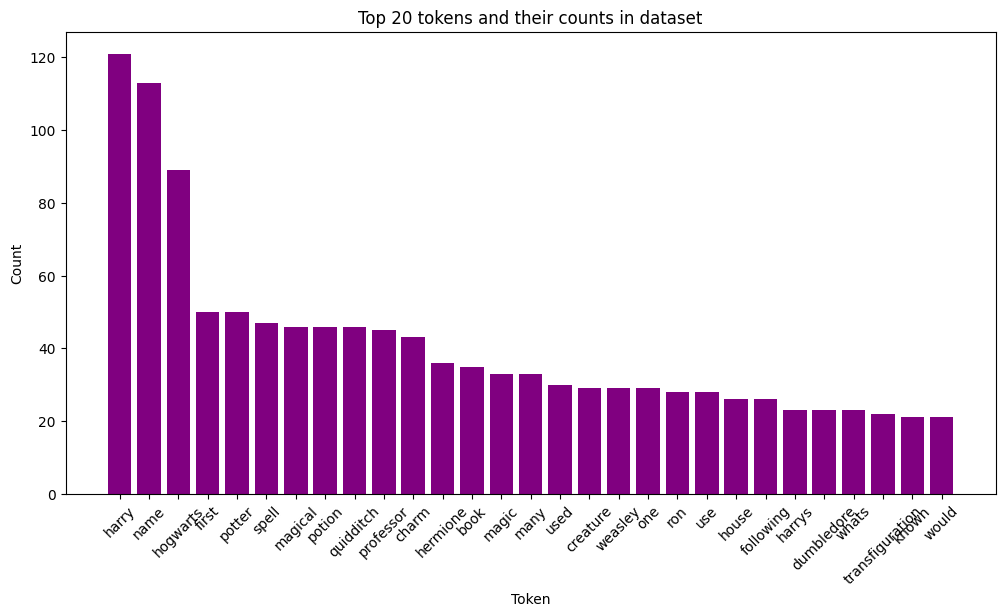

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(filtered_df['token'], filtered_df['count'], color="purple")

plt.xlabel('Token')
plt.ylabel('Count')
plt.title("Top 20 tokens and their counts in dataset")
plt.xticks(rotation=45)
plt.show()

lets look at the rows that have "name" as a keyword.


---
## Adding a `Difficulty` category

For the first iteration of the game, we only need to add a difficulty category to each question. 

There will be three categories ['Easy', 'Medium', 'Hard']. 
The approach will be to:
1. Use a loop to assign categories based on keywords.
   1. categorization based on keyword lists to each difficulty category. Record results in `keyword_difficulty`.
   2. use readability scores like the Flesch-Kincaid readability score or the Gunning Fog Index, which measure the complexity of a text based on sentence length and word difficulty. Can use the textstat library to compute the readability score and assign a difficulty based on that. Record results in `readiblity_score_difficulty`.
2. Review the labels manually and modify as needed. Record results in `final_difficulty`.
   1. review a set number of questions from each category to ensure the labels align. Then expand to full df.
   2. Can also speed up the process, consider using data visualization tools (like word clouds) to see if certain keywords dominate specific categories.
   3. Consider clustering to group questions based on difficulty without needing predefined labels and compare results.
   4. Reiterate cateogry assignment if necessary.

### Keyword-based difficulty categorization

First, let's create keyword lists for each difficulty lists. A generic list was created using ChatGPT-o1 to start with. 

In [13]:
# Predefined keyword dictionary for each difficulty level
keywords = {
    'Easy': [
        'harry', 'ron', 'hermione', 'hogwarts', 'dumbledore', 'voldemort', 'gryffindor', 
        'quidditch', 'wand', 'snape', 'sorting hat', 'expelliarmus', 'hufflepuff', 'slytherin',
        'ravenclaw', 'broom', 'magic'
    ],
    'Medium': [
        'sirius', 'lupin', 'horcrux', 'pensieve', 'room of requirement', 'time-turner', 
        'hippogriff', 'patronus', 'triwizard tournament', 'neville', 'felix felicis', 
        'forbidden forest', 'drumstrang', 'beauxbatons', 'advanced'
    ],
    'Hard': [
        'nurmengard', 'grindelwald', 'occlumency', 'legilimency', 'elder wand', 
        'sectumsempra', 'fiendfyre', 'ariana', 'regulus', 'blood magic', 'thestral', 
        'acromantula'
    ]
}